In [32]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [151]:
X, y = make_blobs(n_samples = 1000, centers = 16, n_features = 5)

In [152]:
X

array([[ -7.01825517,  -1.1472152 ,  10.21346787,  -3.19920251,
         -1.72176672],
       [  8.38885068,  -7.82343443,   0.38608654,  -8.58910346,
          0.05205201],
       [  5.35799946,  -5.32854336,  -7.78862247,  10.25787436,
         -3.72097902],
       ...,
       [  9.05327225,   9.33405818,  -5.27867736,  -6.49008733,
         -9.89716774],
       [-10.53076132,   5.41288965,  -6.97588265,  -2.8385025 ,
          5.99510025],
       [  5.30998987,  -2.37830276,  -3.64350492,   0.6136715 ,
          6.3566175 ]])

In [153]:
y

array([ 1, 11,  3,  2,  4, 10, 14, 14, 13, 15,  6, 15, 10,  4,  7,  5,  3,
       12,  9, 14, 11,  0, 10,  6, 13, 11, 12,  7, 14,  6, 15, 11,  2, 12,
        5, 11,  5,  2, 13,  1, 11,  1,  7, 11, 10, 11,  5,  0,  6, 12, 11,
       15,  9,  0,  2,  5,  0, 15,  5,  7,  8, 13,  7, 11, 11, 10,  6, 14,
        4,  9,  7, 13,  8, 14,  9, 10,  8, 14, 13, 14,  7, 10, 10,  1,  2,
       15, 13,  2, 13, 13,  6,  3, 11,  3, 11, 12, 13,  0, 14, 13, 12,  7,
        7,  5, 14, 14,  4, 11,  7,  3,  1,  4,  3, 13, 12, 11, 14,  6,  9,
        1,  1, 13, 14, 10, 14,  0, 14,  3,  6, 11, 15, 13,  2,  0,  8,  6,
       15,  6, 10,  4, 11,  4,  2, 10,  8, 13,  7,  5,  5,  5, 15, 13,  0,
       11, 12,  4, 10, 13, 13,  8, 11,  7, 14,  7,  6,  3, 14,  2,  9,  8,
       10, 14,  7,  2, 14,  2,  3, 12,  0, 15, 11, 12, 14,  4,  5,  1, 13,
        9,  4, 11, 10, 10,  8,  3,  5,  9, 10, 14,  0,  4,  8,  0, 15,  2,
        5,  9,  5,  9,  2, 11, 15,  1,  4,  6,  2,  9,  2,  3,  0,  6,  4,
        3,  1,  6,  3,  8

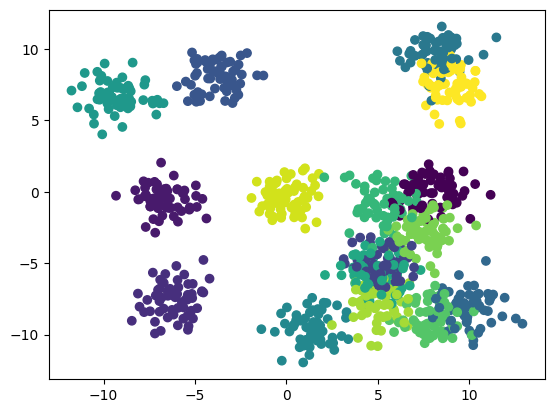

In [165]:
plt.scatter(X[:, 0], X[:, 1], c = y)

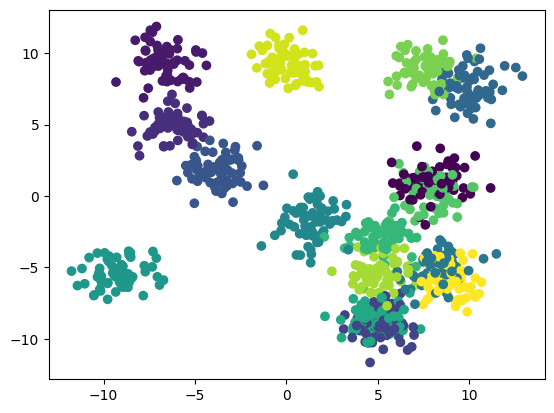

In [166]:
plt.scatter(X[:, 0], X[:, 2], c = y)

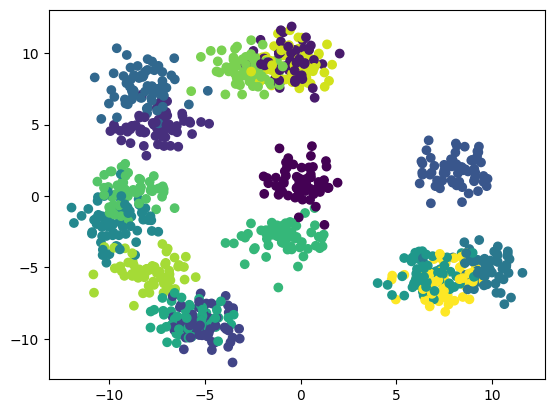

In [167]:
plt.scatter(X[:, 1], X[:, 2], c = y)

In [137]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [154]:
from sklearn.model_selection import train_test_split

In [155]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [156]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [157]:
from sklearn.cluster import KMeans

In [159]:
## Elbow method to select K value, k-means++
wcss = []

for k in range(1, 20):
  kmeans = KMeans(n_clusters = k, init = 'k-means++')
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

In [160]:
wcss

[3350.000000000001,
 2510.1196086373,
 1957.7076223397025,
 1524.8779687061253,
 1156.9969020461972,
 854.2119619473301,
 702.7000347853475,
 574.7876656544706,
 484.8965051532573,
 367.13502523686293,
 314.80508776958214,
 230.96775708269865,
 190.90040200710618,
 154.61818940289623,
 125.04006722187933,
 123.89342960959769,
 93.5401747724655,
 92.2689818563812,
 90.707296548518]

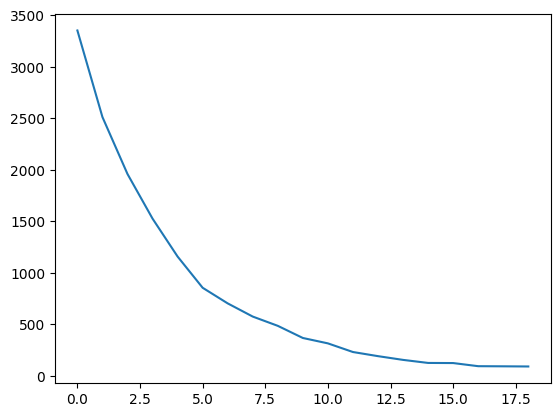

In [161]:
plt.plot(wcss)

In [147]:
## Elbow method to select K value, random
wcss2 = []

for k in range(1, 20):
  kmeans2 = KMeans(n_clusters = k, init = 'random')
  kmeans2.fit(X_train_scaled)
  wcss2.append(kmeans2.inertia_)

In [78]:
wcss2

[2009.9999999999998,
 1109.3352984112482,
 462.67050756604675,
 170.39122186250174,
 71.43387053837962,
 66.35727328415625,
 62.36453743670205,
 58.959005081956974,
 54.53067699205273,
 53.38517396788996]

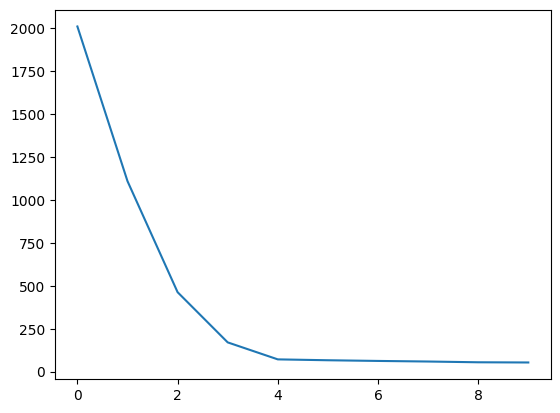

In [79]:
plt.plot(wcss2)

In [112]:
# Elbow is at 5 clusters
kmeans = KMeans(n_clusters = 5, init = 'k-means++')
kmeans.fit(X_train_scaled)

KMeans(n_clusters=5)

In [113]:
# Accuracy
kmeans.score(X_train_scaled), kmeans.score(X_test_scaled)

(-90.52472529928488, -47.90786966865757)

In [116]:
y_pred = kmeans.predict(X_test_scaled)
y_pred

array([4, 2, 2, 1, 4, 1, 4, 0, 3, 1, 3, 2, 2, 4, 2, 2, 4, 1, 2, 1, 4, 2,
       1, 3, 3, 2, 4, 2, 4, 0, 4, 1, 1, 3, 1, 0, 0, 0, 2, 3, 2, 2, 1, 1,
       2, 1, 1, 3, 1, 2, 3, 3, 4, 1, 3, 4, 4, 4, 3, 1, 1, 0, 1, 2, 1, 2,
       0, 0, 3, 3, 4, 4, 3, 4, 1, 1, 4, 4, 3, 1, 4, 1, 2, 4, 0, 1, 2, 3,
       2, 0, 4, 3, 0, 4, 1, 4, 0, 0, 0, 3, 3, 1, 1, 0, 2, 0, 2, 2, 2, 0,
       0, 0, 3, 2, 1, 3, 3, 2, 3, 1, 1, 4, 2, 1, 3, 1, 0, 4, 2, 3, 4, 4,
       3, 3, 2, 0, 4, 0, 0, 0, 2, 0, 0, 3, 0, 4, 2, 0, 4, 3, 1, 0, 4, 1,
       0, 4, 4, 2, 2, 1, 3, 2, 3, 4, 4, 2, 4, 1, 0, 3, 3, 1, 1, 0, 0, 0,
       3, 4, 0, 4, 1, 4, 2, 2, 0, 4, 3, 0, 0, 1, 0, 3, 4, 2, 2, 1, 2, 2,
       4, 3, 2, 1, 2, 4, 1, 4, 4, 2, 1, 0, 3, 1, 3, 2, 3, 0, 0, 4, 2, 2,
       2, 3, 4, 3, 2, 4, 3, 3, 4, 3, 0, 3, 3, 2, 3, 0, 2, 0, 2, 1, 1, 4,
       3, 4, 4, 1, 4, 2, 1, 4, 2, 1, 4, 3, 0, 0, 2, 4, 0, 3, 4, 3, 3, 3,
       2, 0, 2, 0, 3, 2, 3, 3, 3, 3, 1, 4, 0, 4, 3, 4, 3, 2, 1, 2, 3, 0,
       3, 3, 1, 0, 1, 1, 0, 2, 3, 0, 2, 0, 4, 0, 1,

In [117]:
y_test

array([0, 4, 4, 3, 0, 3, 0, 2, 1, 3, 1, 4, 4, 0, 4, 4, 0, 3, 4, 3, 0, 4,
       3, 1, 1, 4, 0, 4, 0, 2, 0, 3, 3, 1, 3, 2, 2, 2, 4, 1, 4, 4, 3, 3,
       4, 3, 3, 1, 3, 4, 1, 1, 0, 3, 1, 0, 0, 0, 1, 3, 3, 2, 3, 4, 3, 4,
       2, 2, 1, 1, 0, 0, 1, 0, 3, 3, 0, 0, 1, 3, 0, 3, 4, 0, 2, 3, 4, 1,
       4, 2, 0, 1, 2, 0, 3, 0, 2, 2, 2, 1, 1, 3, 3, 2, 4, 2, 4, 4, 4, 2,
       2, 2, 1, 4, 3, 1, 1, 4, 1, 3, 3, 0, 4, 3, 1, 3, 2, 0, 4, 1, 0, 0,
       1, 1, 4, 2, 0, 2, 2, 2, 4, 2, 2, 1, 2, 0, 4, 2, 0, 1, 3, 2, 0, 3,
       2, 0, 0, 4, 4, 3, 1, 4, 1, 0, 0, 4, 0, 3, 2, 1, 1, 3, 3, 2, 2, 2,
       1, 0, 2, 0, 3, 0, 4, 4, 2, 0, 1, 2, 2, 3, 2, 1, 0, 4, 4, 3, 4, 4,
       0, 1, 4, 3, 4, 0, 3, 0, 0, 4, 3, 2, 1, 3, 1, 4, 1, 2, 2, 0, 4, 4,
       4, 1, 0, 1, 4, 0, 1, 1, 0, 1, 2, 1, 1, 4, 1, 2, 4, 2, 4, 3, 3, 0,
       1, 0, 0, 3, 0, 4, 3, 0, 4, 3, 0, 1, 2, 2, 4, 0, 2, 1, 0, 1, 1, 1,
       4, 2, 4, 2, 1, 4, 1, 1, 1, 1, 3, 0, 2, 0, 1, 0, 1, 4, 3, 4, 1, 2,
       1, 1, 3, 2, 3, 3, 2, 4, 1, 2, 4, 2, 0, 2, 3,

In [123]:
!pip install kneed

In [162]:
from kneed import KneeLocator

In [163]:
kl = KneeLocator(range(1, 20), wcss, curve='convex', direction='decreasing')

In [168]:
kl.elbow

np.int64(6)

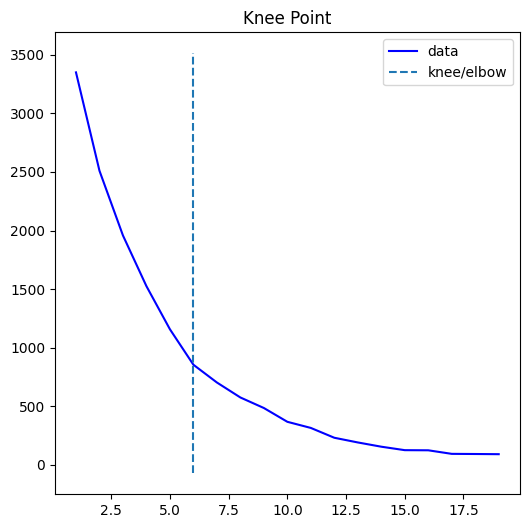

In [164]:
#plot the kl
kl.plot_knee()

In [170]:
## Silhoutte score
from sklearn.metrics import silhouette_score

In [181]:
silhouette_coefficients = []
for k in range(2, 20):
  kmeans3 = KMeans(n_clusters = k, init = 'k-means++')
  kmeans3.fit(X_train_scaled)
  score = silhouette_score(X_train_scaled, kmeans3.labels_)
  silhouette_coefficients.append(score)

In [182]:
silhouette_coefficients

[np.float64(0.292553593492347),
 np.float64(0.3113545634921709),
 np.float64(0.37826541208179726),
 np.float64(0.4238842696627851),
 np.float64(0.4555898459040605),
 np.float64(0.4841353340369496),
 np.float64(0.5400688788135146),
 np.float64(0.49696834842799764),
 np.float64(0.5776825014372935),
 np.float64(0.6113220458108265),
 np.float64(0.626851466610125),
 np.float64(0.6466289109889417),
 np.float64(0.6098662170991581),
 np.float64(0.6514917717755206),
 np.float64(0.6612976404023143),
 np.float64(0.6295787226987756),
 np.float64(0.6260487647430766),
 np.float64(0.5608744087971557)]

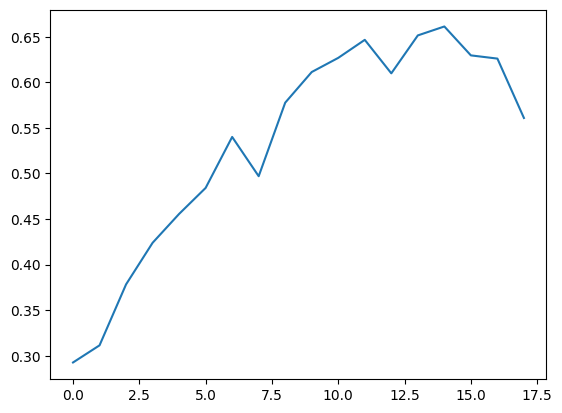

In [183]:
plt.plot(silhouette_coefficients)

## Trying K Median

In [84]:
def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

def kmedians(X, k, max_iters=100, tol=1e-4, random_state=None):
    np.random.seed(random_state)

    # Step 1: Initialize cluster centers randomly
    indices = np.random.choice(len(X), k, replace=False)
    centers = X[indices]

    for _ in range(max_iters):
        distances = np.zeros((len(X), k))

        # Step 2: Compute distances from each point to each center
        for i, x in enumerate(X):
            for j, c in enumerate(centers):
                distances[i, j] = manhattan_distance(x, c)

        # Step 3: Assign each point to nearest cluster
        labels = np.argmin(distances, axis=1)

        new_centers = np.copy(centers)

        # Step 4: Recompute cluster centers as median of assigned points
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                new_centers[i] = np.median(cluster_points, axis=0)

        # Step 5: Check convergence
        if np.all(np.abs(new_centers - centers) < tol):
            break

        centers = new_centers

    # Optional: compute total within-cluster distance
    total_distance = np.sum([distances[i, labels[i]] for i in range(len(X))])

    return centers, labels, distances, total_distance

In [89]:
## Elbow method to select K value, random
distances_list = []

for k in range(1, 11):
  centers, labels, distances, total_distance = kmedians(X_train_scaled, k=k, random_state=42)
  distances_list.append(total_distance)


In [90]:
distances_list

[np.float64(1625.3756277199027),
 np.float64(1148.9017969850943),
 np.float64(826.9534943483225),
 np.float64(622.0725240951559),
 np.float64(298.9017844186545),
 np.float64(288.6255515702776),
 np.float64(279.50449789835585),
 np.float64(272.71080883896093),
 np.float64(264.28389657786926),
 np.float64(259.1539669274867)]